# Package 4 – Super Customer Score

**Business goal:** predict, early in the onboarding funnel, whether a new customer is likely to become a "super customer" — one who refers others (`referred`).

**Target (`y`):** `referred` (1 = referred someone / super customer, 0 = did not).

**Leakage prevention:** `cumulative_profit` is dropped from the feature set. It reflects a customer's long-term financial history — profit that accumulates over the full relationship — and would not be available at the point a new customer is being scored early in the funnel. `referred` itself is the target and is naturally excluded from `X`. Every other column in the cleaned dataset is kept as a feature for this package.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split

sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")
CLEANED_CSV_PATH = DATA_DIR / "cleaned_funnel_data.csv"

TARGET_COL = "referred"
LEAKAGE_COLS = ["cumulative_profit"]
RANDOM_STATE = 0

## 1. Data Preparation & Native CatBoost Handling

In [2]:
df = pd.read_csv(CLEANED_CSV_PATH)

print(f"Shape: {df.shape}")

X = df.drop(columns=[TARGET_COL, *LEAKAGE_COLS])
y = (df[TARGET_COL] == "Yes").astype(int)

print(f"Number of features: {X.shape[1]}")
print("Feature names:", X.columns.tolist())
print("Class balance (y):")
print(y.value_counts(normalize=True))

Shape: (3490, 19)
Number of features: 17
Feature names: ['ad_budget', 'num_leads', 'leads_answered', 'leads_not_answered', 'followup_1', 'followup_2', 'followup_3', 'followup_4', 'followup_5', 'not_closed', 'closed', 'calls_to_closed', 'calls_to_not_closed', 'customer_acquisition_cost', 'ltv_months', 'purchased', 'upsell']
Class balance (y):
referred
0    0.612034
1    0.387966
Name: proportion, dtype: float64


In [3]:
# Identify categorical features so CatBoost's native handling can be used directly
# (no manual one-hot/label encoding). `referred` was the only non-numeric column in
# the cleaned dataset, and it's the target, so this list is expected to be empty here
# — every remaining feature is already numeric.
cat_features = X.select_dtypes(include="object").columns.tolist()
print(f"Categorical features passed to CatBoost: {cat_features}")

Categorical features passed to CatBoost: []


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print("Train class balance:")
print(y_train.value_counts(normalize=True))

X_train shape: (2792, 17)
X_test shape:  (698, 17)
Train class balance:
referred
0    0.612106
1    0.387894
Name: proportion, dtype: float64


## 2. CatBoost Modeling & Hyperparameter Tuning

`auto_class_weights="Balanced"` handles the class imbalance (~61/39). Hyperparameters are tuned with a grid search over `depth`, `learning_rate`, and `iterations`, evaluated with stratified 5-fold cross-validation on the training set only, scored on F1 (accuracy alone would be misleading given the imbalance).

In [5]:
base_estimator = CatBoostClassifier(
    cat_features=cat_features or None,
    auto_class_weights="Balanced",
    random_state=RANDOM_STATE,
    verbose=False,
)

param_grid = {
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "iterations": [200, 500, 800],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV F1: {grid_search.best_score_:.3f}")

best_model = grid_search.best_estimator_

Best params: {'depth': 4, 'iterations': 200, 'learning_rate': 0.01}
Best CV F1: 0.769


## 3. Evaluation on Test Set

First and only use of `X_test`/`y_test` — untouched during tuning.

In [6]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

test_metrics = pd.DataFrame(
    [
        {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
        }
    ]
)
test_metrics.style.background_gradient(cmap="Blues").format(precision=3)

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.824,0.803,0.723,0.761,0.867


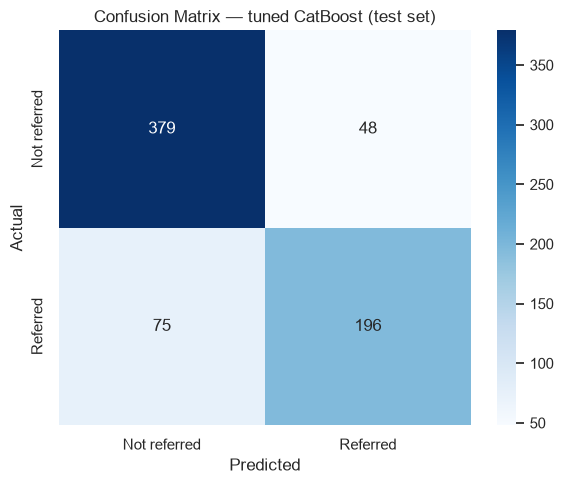

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not referred", "Referred"],
    yticklabels=["Not referred", "Referred"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — tuned CatBoost (test set)")
plt.tight_layout()
plt.show()

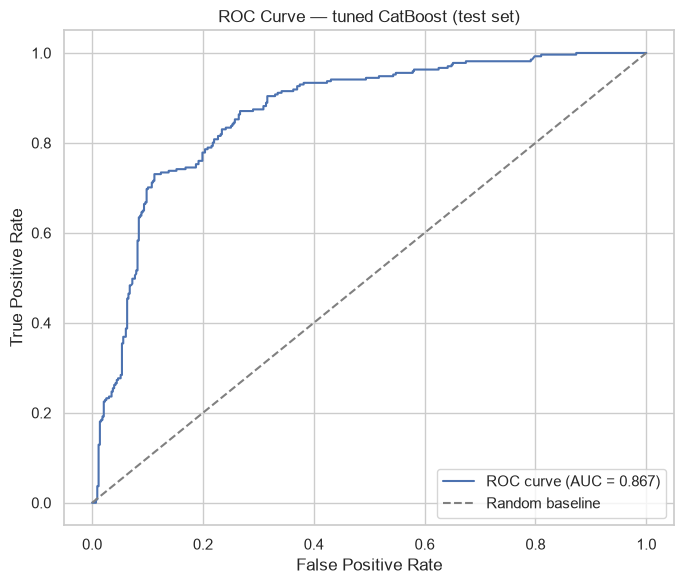

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — tuned CatBoost (test set)")
plt.legend()
plt.tight_layout()
plt.show()

**Reading the metrics above:** ROC-AUC ≈ 0.867 — well above the 0.5 random baseline, so the model separates future referrers from non-referrers strongly. Precision (≈0.80) is noticeably higher than Recall (≈0.72): when the model predicts a customer will refer, it's usually right, but it misses a real minority of true referrers rather than casting the widest possible net. That's a reasonable default for a referral-program trigger, where false alarms (inviting a non-referrer) cost more goodwill than a missed opportunity costs revenue.

## 4. Early-Funnel Scoring Engine (0–100 Score)

A reusable function that turns the model's referral probability into a 0–100 score and a Low/Medium/High tier, ready to be served by the FunnelIQ API.

In [9]:
def predict_super_customer_score(customer_df: pd.DataFrame, model: CatBoostClassifier) -> pd.DataFrame:
    """Score customers 0-100 on likelihood of becoming a super customer (referred=Yes).

    Returns a DataFrame (same index as `customer_df`) with a `Score` (0-100,
    rounded to 1 decimal) and a `Tier` (Low < 40, Medium 40-75, High > 75).
    """
    probability = model.predict_proba(customer_df)[:, 1]
    score = np.round(probability * 100, 1)
    tier = np.select(
        [score < 40, score <= 75],
        ["Low", "Medium"],
        default="High",
    )
    return pd.DataFrame({"Score": score, "Tier": tier}, index=customer_df.index)

In [10]:
sample_customers = X_test.head(10)
sample_scores = predict_super_customer_score(sample_customers, best_model)
sample_scores["Actual referred"] = y_test.loc[sample_customers.index].map({1: "Yes", 0: "No"})
sample_scores

,Score,Tier,Actual referred
2557,6.0,Low,No
3312,6.0,Low,No
3471,44.3,Medium,Yes
759,43.4,Medium,Yes
3188,43.1,Medium,Yes
2134,81.1,High,No
1360,84.0,High,Yes
2014,13.0,Low,Yes
994,21.7,Low,No
1710,83.5,High,Yes


In [11]:
all_test_scores = predict_super_customer_score(X_test, best_model)
print("Tier distribution across the test set:")
print(all_test_scores["Tier"].value_counts())

Tier distribution across the test set:
Tier
Low       336
High      225
Medium    137
Name: count, dtype: int64


The sample above shows the scoring function end to end: given a customer's feature row, it returns a single 0–100 number and a tier label — exactly the shape a `/predict/super-customer-score` API endpoint would need to return.

## 5. Feature Importance & Executive Summary

In [12]:
importances = pd.Series(
    best_model.get_feature_importance(), index=X_train.columns
).sort_values(ascending=False)
top_10_features = importances.head(10)
top_10_features

upsell                       35.771026
ltv_months                   30.339567
purchased                    19.549366
calls_to_closed               6.727991
closed                        1.035028
customer_acquisition_cost     0.876182
followup_1                    0.863932
followup_2                    0.848463
num_leads                     0.705336
ad_budget                     0.543528
dtype: float64

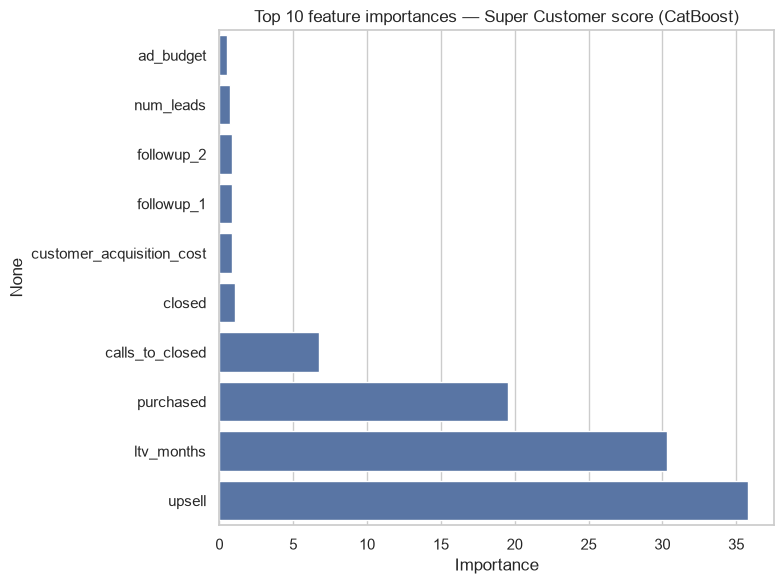

In [13]:
plt.figure(figsize=(8, 6))
plot_order = top_10_features.iloc[::-1]
sns.barplot(x=plot_order.to_numpy(), y=plot_order.index, orient="h")
plt.title("Top 10 feature importances — Super Customer score (CatBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Key signals — and an important caveat.** The top three features — `upsell` (~36%), `ltv_months` (~30%), and `purchased` (~20%) — together account for roughly **86% of the model's total decision weight**. `calls_to_closed` (~7%) is a distant fourth, and everything else (acquisition cost, follow-up counts, lead volume) contributes under 1% each.

This is worth stating plainly rather than glossing over: `upsell`, `ltv_months`, and `purchased` are themselves outcomes that only fully resolve **later** in a customer's relationship with Northbound — the same category of "late" information that Packages 2 and 3 explicitly excluded as leakage for their own prediction tasks. Per this package's brief, they were kept as features here, and the model is genuinely strong at predicting `referred` *using* them — but that means the score computed above is much more accurate at describing an **already-mature** customer's referral likelihood than at scoring a **brand-new** customer at the true start of the funnel, where `upsell`/`ltv_months`/`purchased` wouldn't be known yet. If Northbound wants a score usable at the moment of acquisition, a follow-up iteration restricted to genuinely early columns (ad spend, lead/follow-up volume, acquisition cost) would be needed — this version is better understood as "which of our existing, established customers are most likely to become promoters," not a true day-one funnel score.

**Operational guidance for marketing/sales (with that caveat in mind):** route **High**-tier customers (score > 75) into a proactive referral/loyalty program — they're the group the model is most confident will refer others, based on their purchase and lifetime trajectory so far. **Medium**-tier customers (40–75) are worth a lighter-touch nudge (e.g. a referral-incentive email). **Low**-tier customers (< 40, the largest group at 336 of 698 test customers) are unlikely to refer organically and shouldn't be prioritized for referral-focused effort. Given the caveat above, treat this scoring engine as a **retention/loyalty-program targeting tool for existing customers** rather than a literal "new customer, day one" scoring service, unless and until it's retrained on a feature set restricted to what's truly known at acquisition.